# Отчет по решению ОДУ: $y' + ky = f$

**Цель:** Сравнить численное решение (центральные разности) с аналитическим при разных параметрах $k$.


**Метод:** Итерационный метод на C++/Python.

Для уравнения $y' + ky = f$ на сетке с шагом $h$ центральная разность выглядит так:

1. Аппроксимация производной.  Мы заменяем $y'$ в каждой точке $i$ (кроме границ) на:$$\frac{y_{i+1} - y_{i-1}}{2h}$$
Подставляем это в исходное уравнение $y' + ky = f$:$$\frac{y_{i+1} - y_{i-1}}{2h} + k y_i = f_i$$
2. Коэффициенты матрицы.  Чтобы составить СЛАУ $Ay = b$, нам нужно вытащить коэффициенты при $y_{i-1}$, $y_i$ и $y_{i+1}$. Умножим всё уравнение на $2h$, чтобы избавиться от знаменателя:$$(y_{i+1} - y_{i-1}) + 2hk \cdot y_i = 2hf_i$$Перегруппируем, чтобы увидеть структуру строки матрицы:$$-1 \cdot y_{i-1} + (2hk) \cdot y_i + 1 \cdot y_{i+1} = 2hf_i$$Отсюда получаем элементы нашей трехдиагональной матрицы:Левая диагональ ($A[i][i-1]$): $a = -1$Центральная диагональ ($A[i][i]$): $c = 2hk$Правая диагональ ($A[i][i+1]$): $b = 1$Правая часть ($b_i$): $2hf$
3. Граничные условия.  (Первая и последняя строки)Матрица не может быть бесконечной, поэтому для краев мы просто фиксируем значения:Для первой строки ($i=0$):$$y_0 = \text{const}$$(В матрице это $A[0][0] = 1$, остальные нули в строке, $b_0 = y_{start}$)Для последней строки ($i=n-1$):$$y_{n-1} = \text{const}$$(В матрице это $A[n-1][n-1] = 1$, остальные нули в строке, $b_{n-1} = y_{end}$)
4. Условие сходимости.  (Диагональное преобладание)Чтобы итерации не разлетались, центральный элемент должен быть больше суммы боковых по модулю:$$|2hk| > |-1| + |1| \implies 2hk > 2 \implies hk > 1$$Если это условие не выполняется (маленькое $k$ или очень мелкий шаг $h$), матрица теряет устойчивость, и становится видно "пилу". Поэтому либо необходимо брать большие отрезки и шаг побольше, либо ограничиваться решениями для $k>=1/h$

## Анализ работы солвера

### 1. Верификация алгоритма
Из-за специфики решаемой задачи (краевая задача для ОДУ) система формирует **трехдиагональные матрицы**. Для проверки корректности работы итерационного метода на C++ были выбраны тестовые матрицы размерностей **5x5, 6x6 и 7x7**. Ниже представлены зависимости сходимости (графики невязки).

---

### 2. Решение основной задачи
После верификации солвер был применен к расчету СЛАУ, полученной при дискретизации уравнения $y' + ky = f$. Расчет проводился на отрезке $[0:1]$ для трех значений параметра **k**, определяющего жесткость уравнения, при краевом условии $y(0)=0$. Правая граница вычислялась аналитически.

#### Результаты и вычислительная сложность:
Несмотря на внешнюю схожесть графиков (все решения выходят на асимптоту $f/k$), количество итераций для достижения точности $10^{-7}$ существенно различается:
* **k = 1.0:** ~2.2 млн итераций (высокая вычислительная сложность).
* **k = 10.0:** ~22 тыс. итераций.
* **k = 50.0:** ~860 итераций (мгновенная сходимость).

Это объясняется тем, что при больших $k$ диагональное преобладание в матрице становится более выраженным, что ускоряет сходимость метода простых итераций.

--- ЭМБЕДИНГ КАРТИНОК ДЛЯ ЭКСПОРТА ---



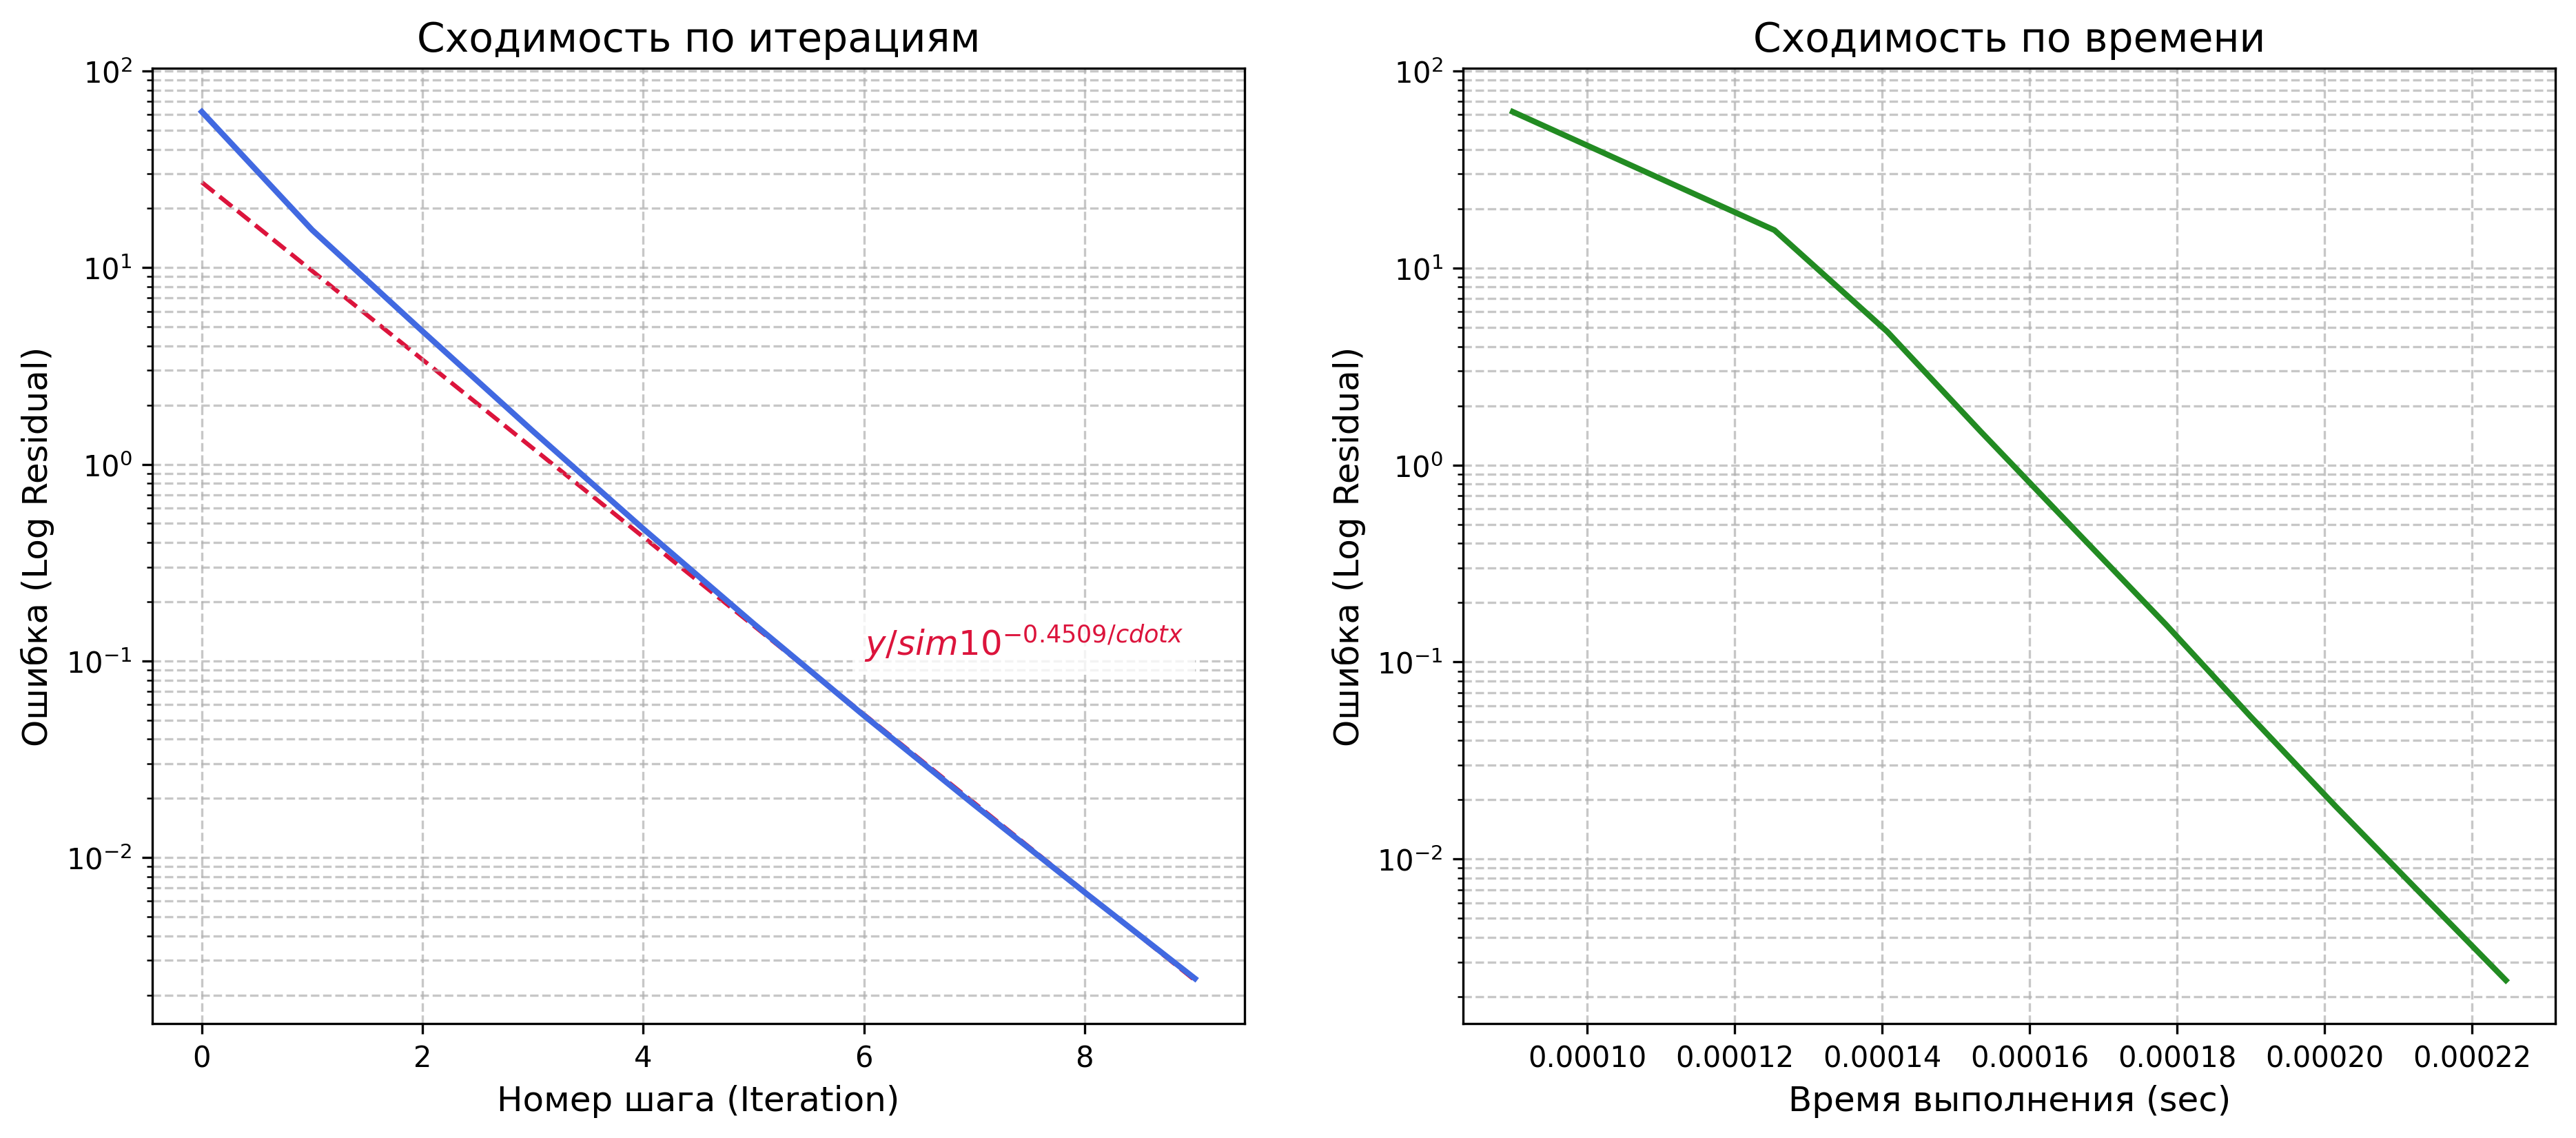


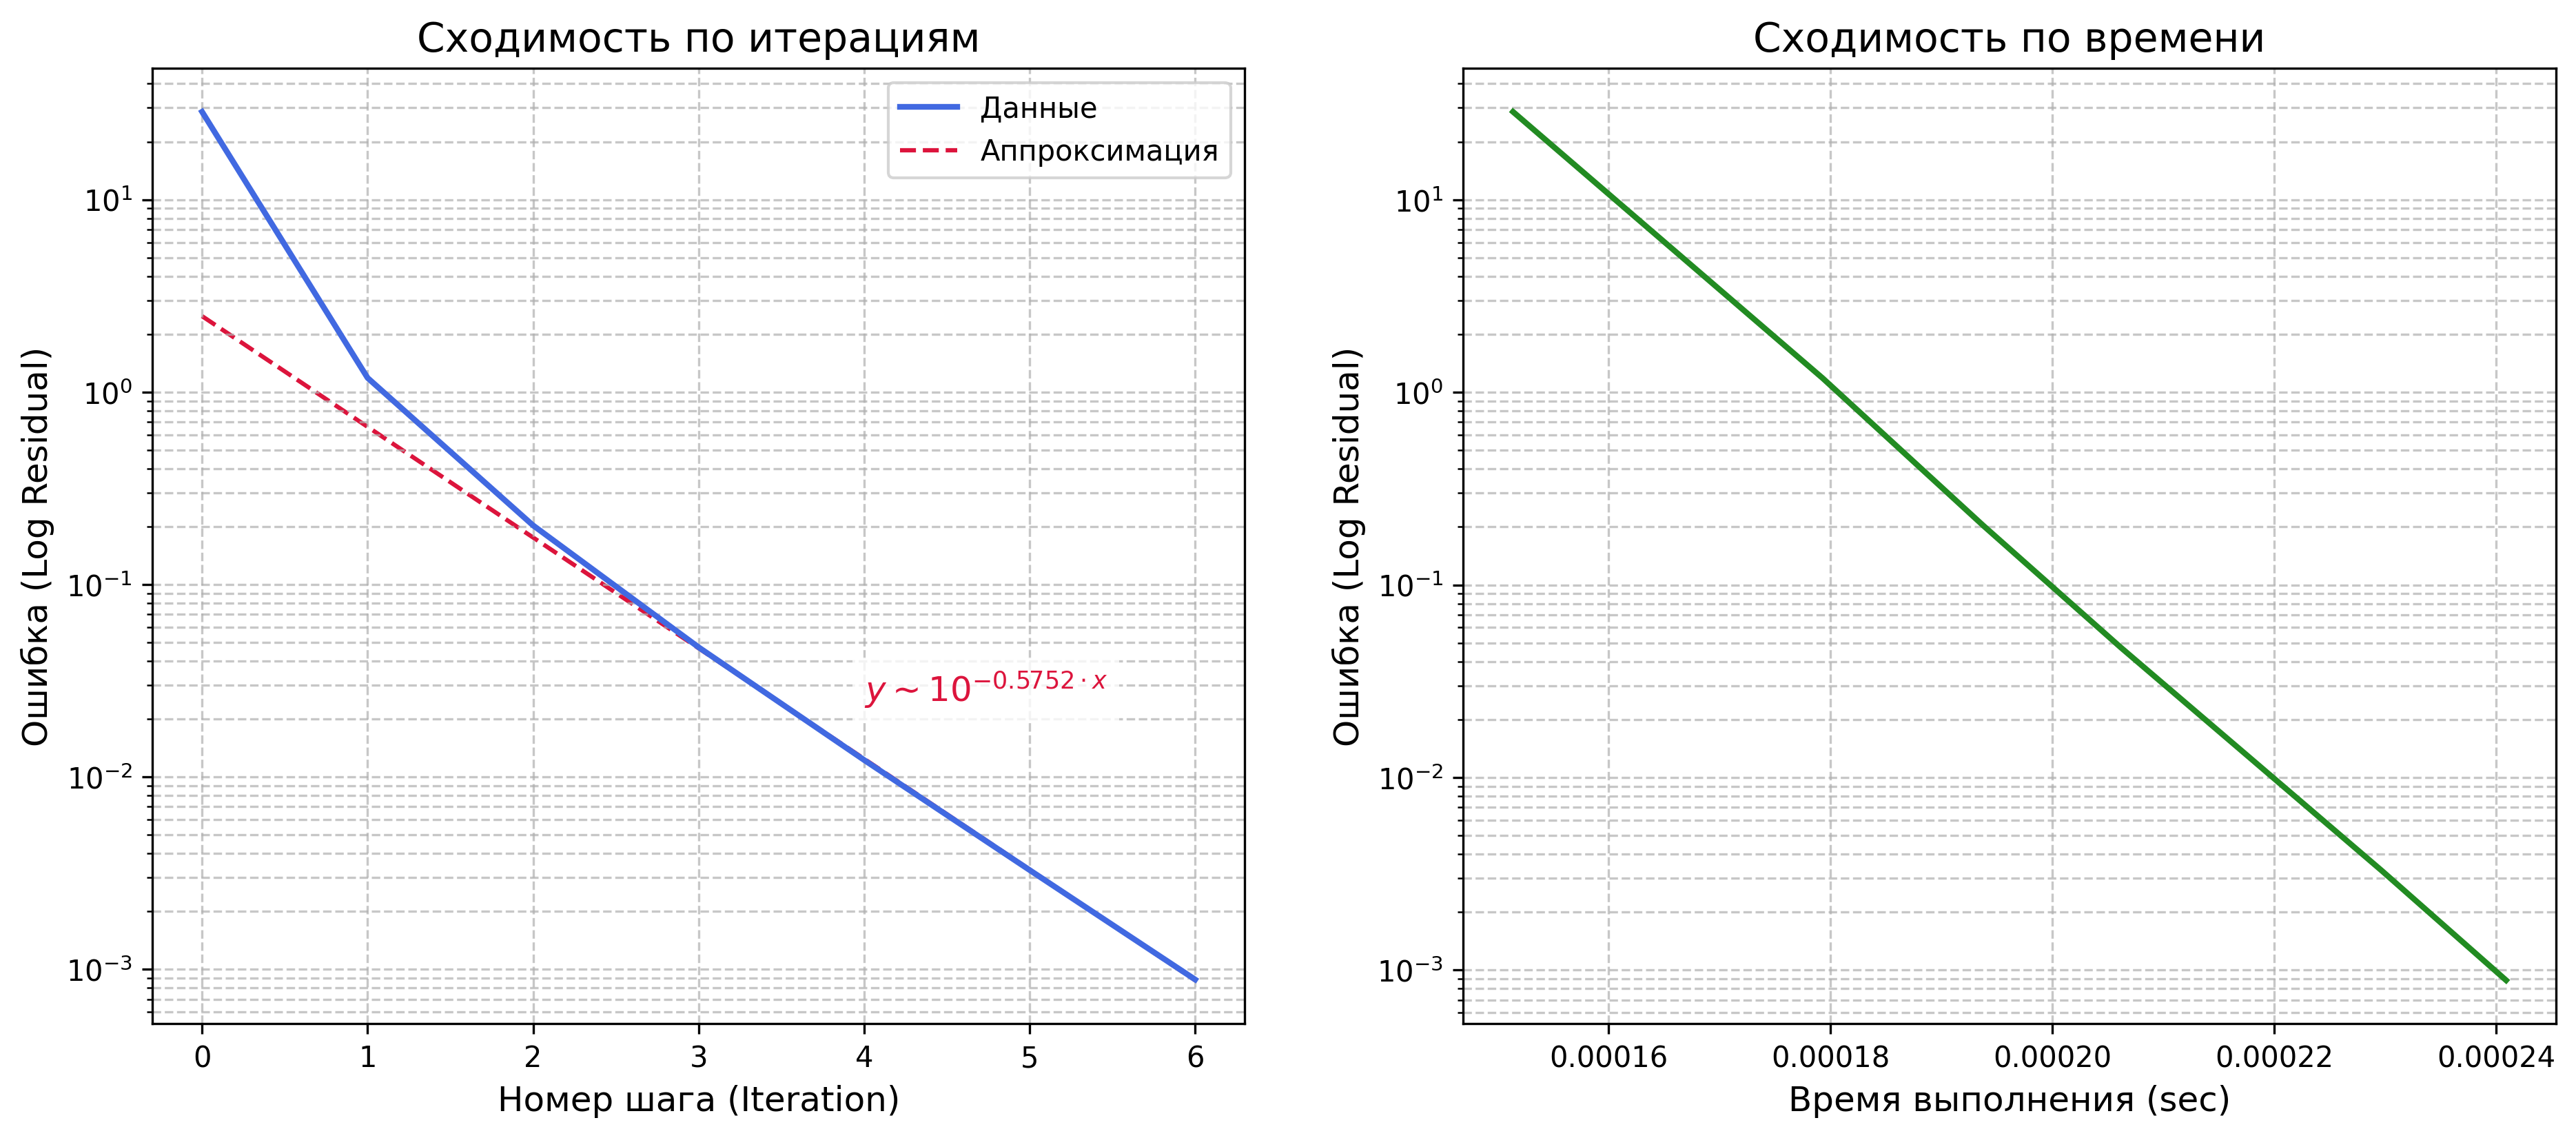


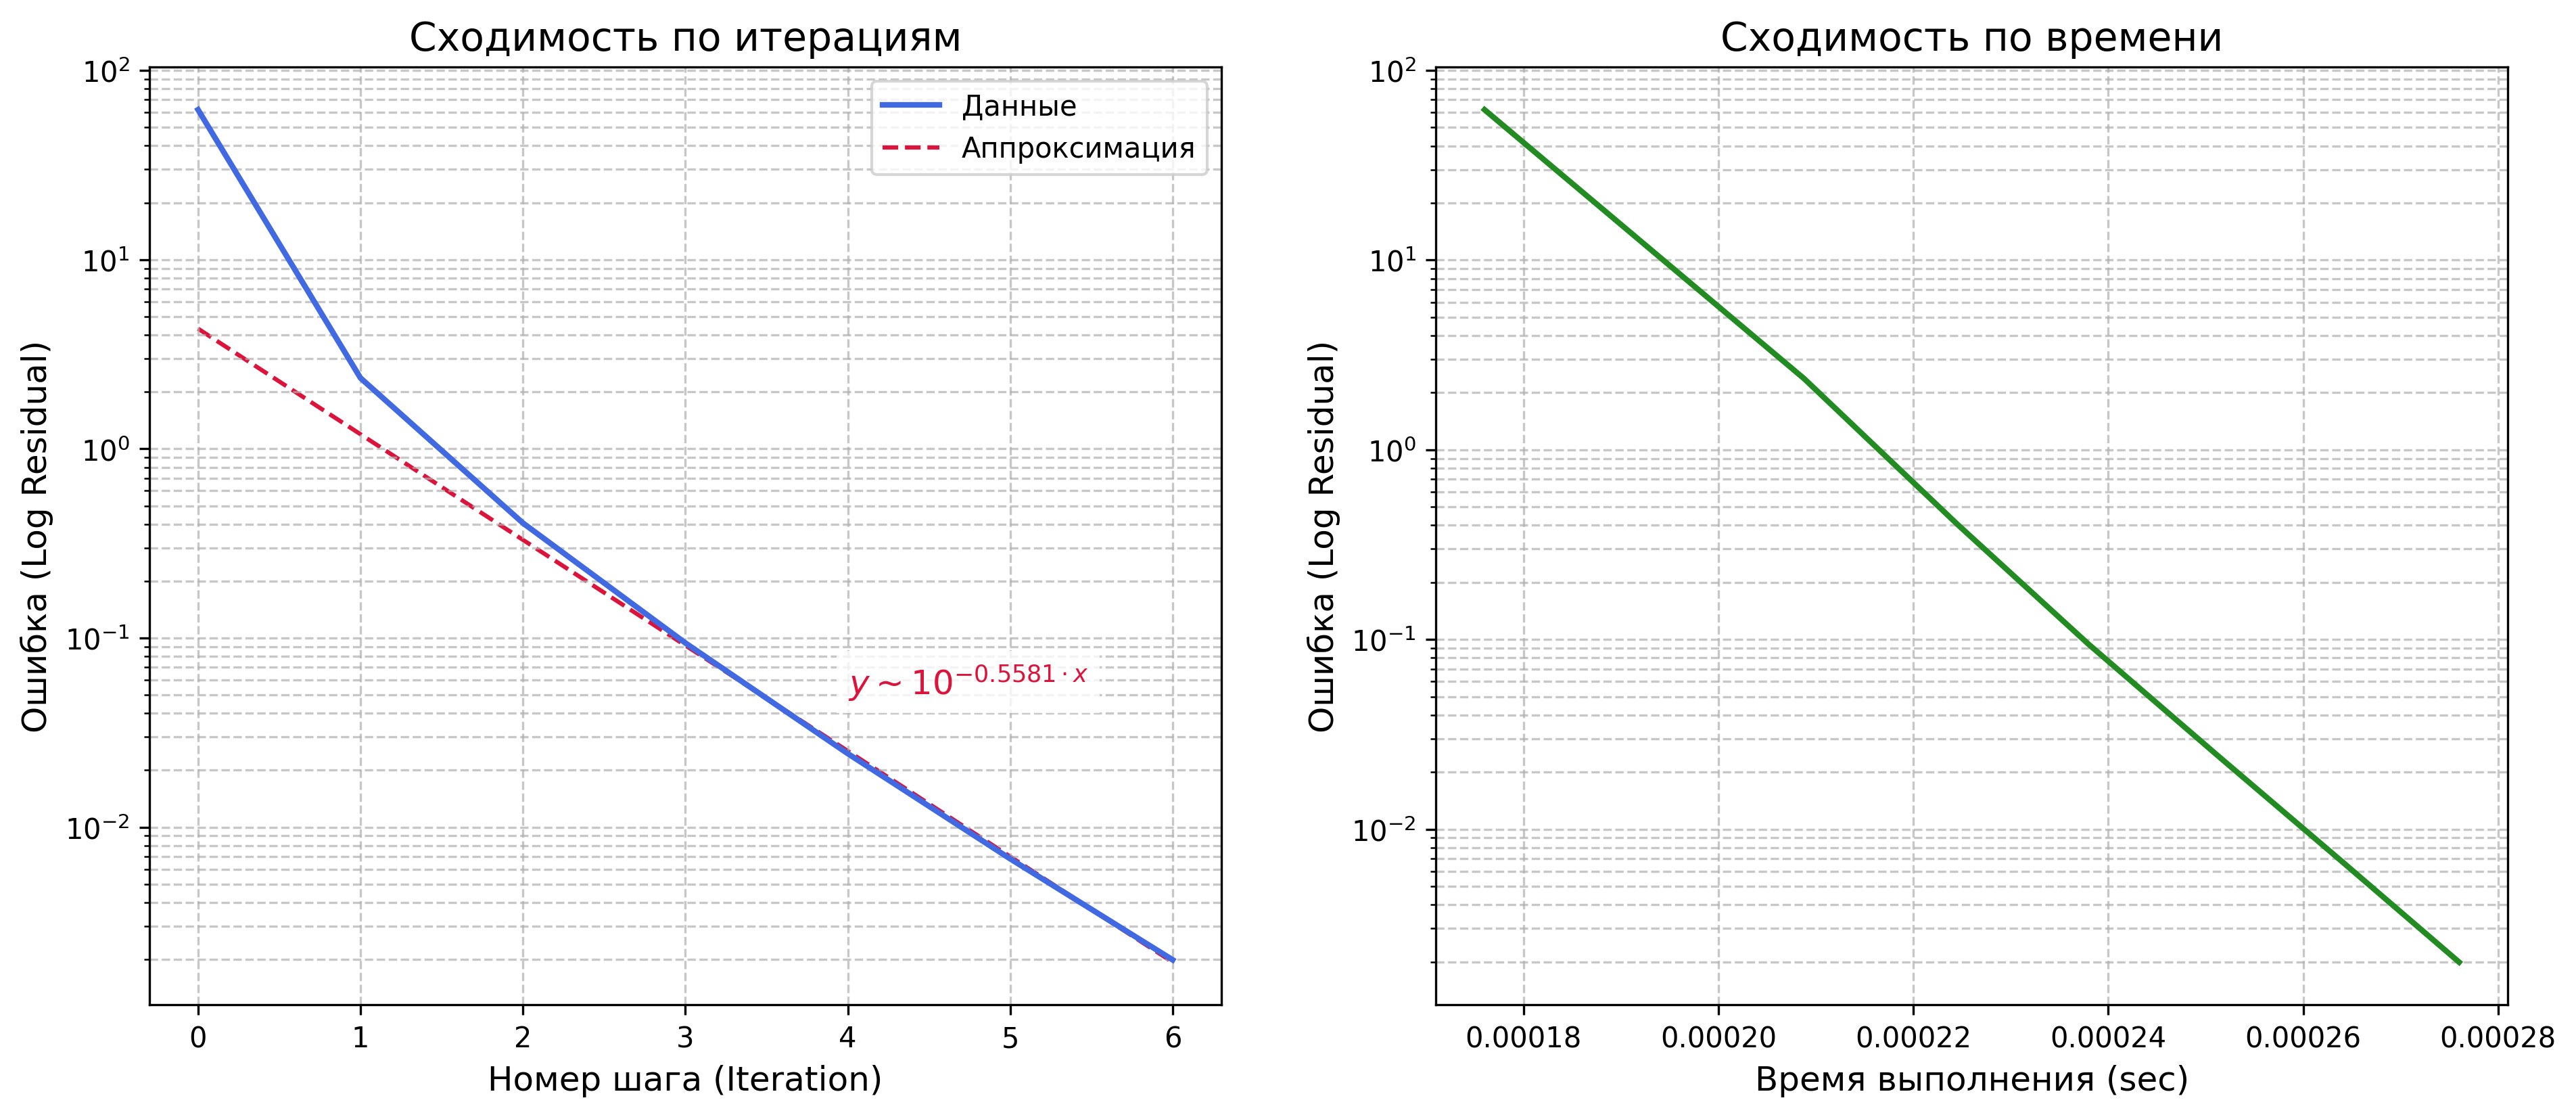


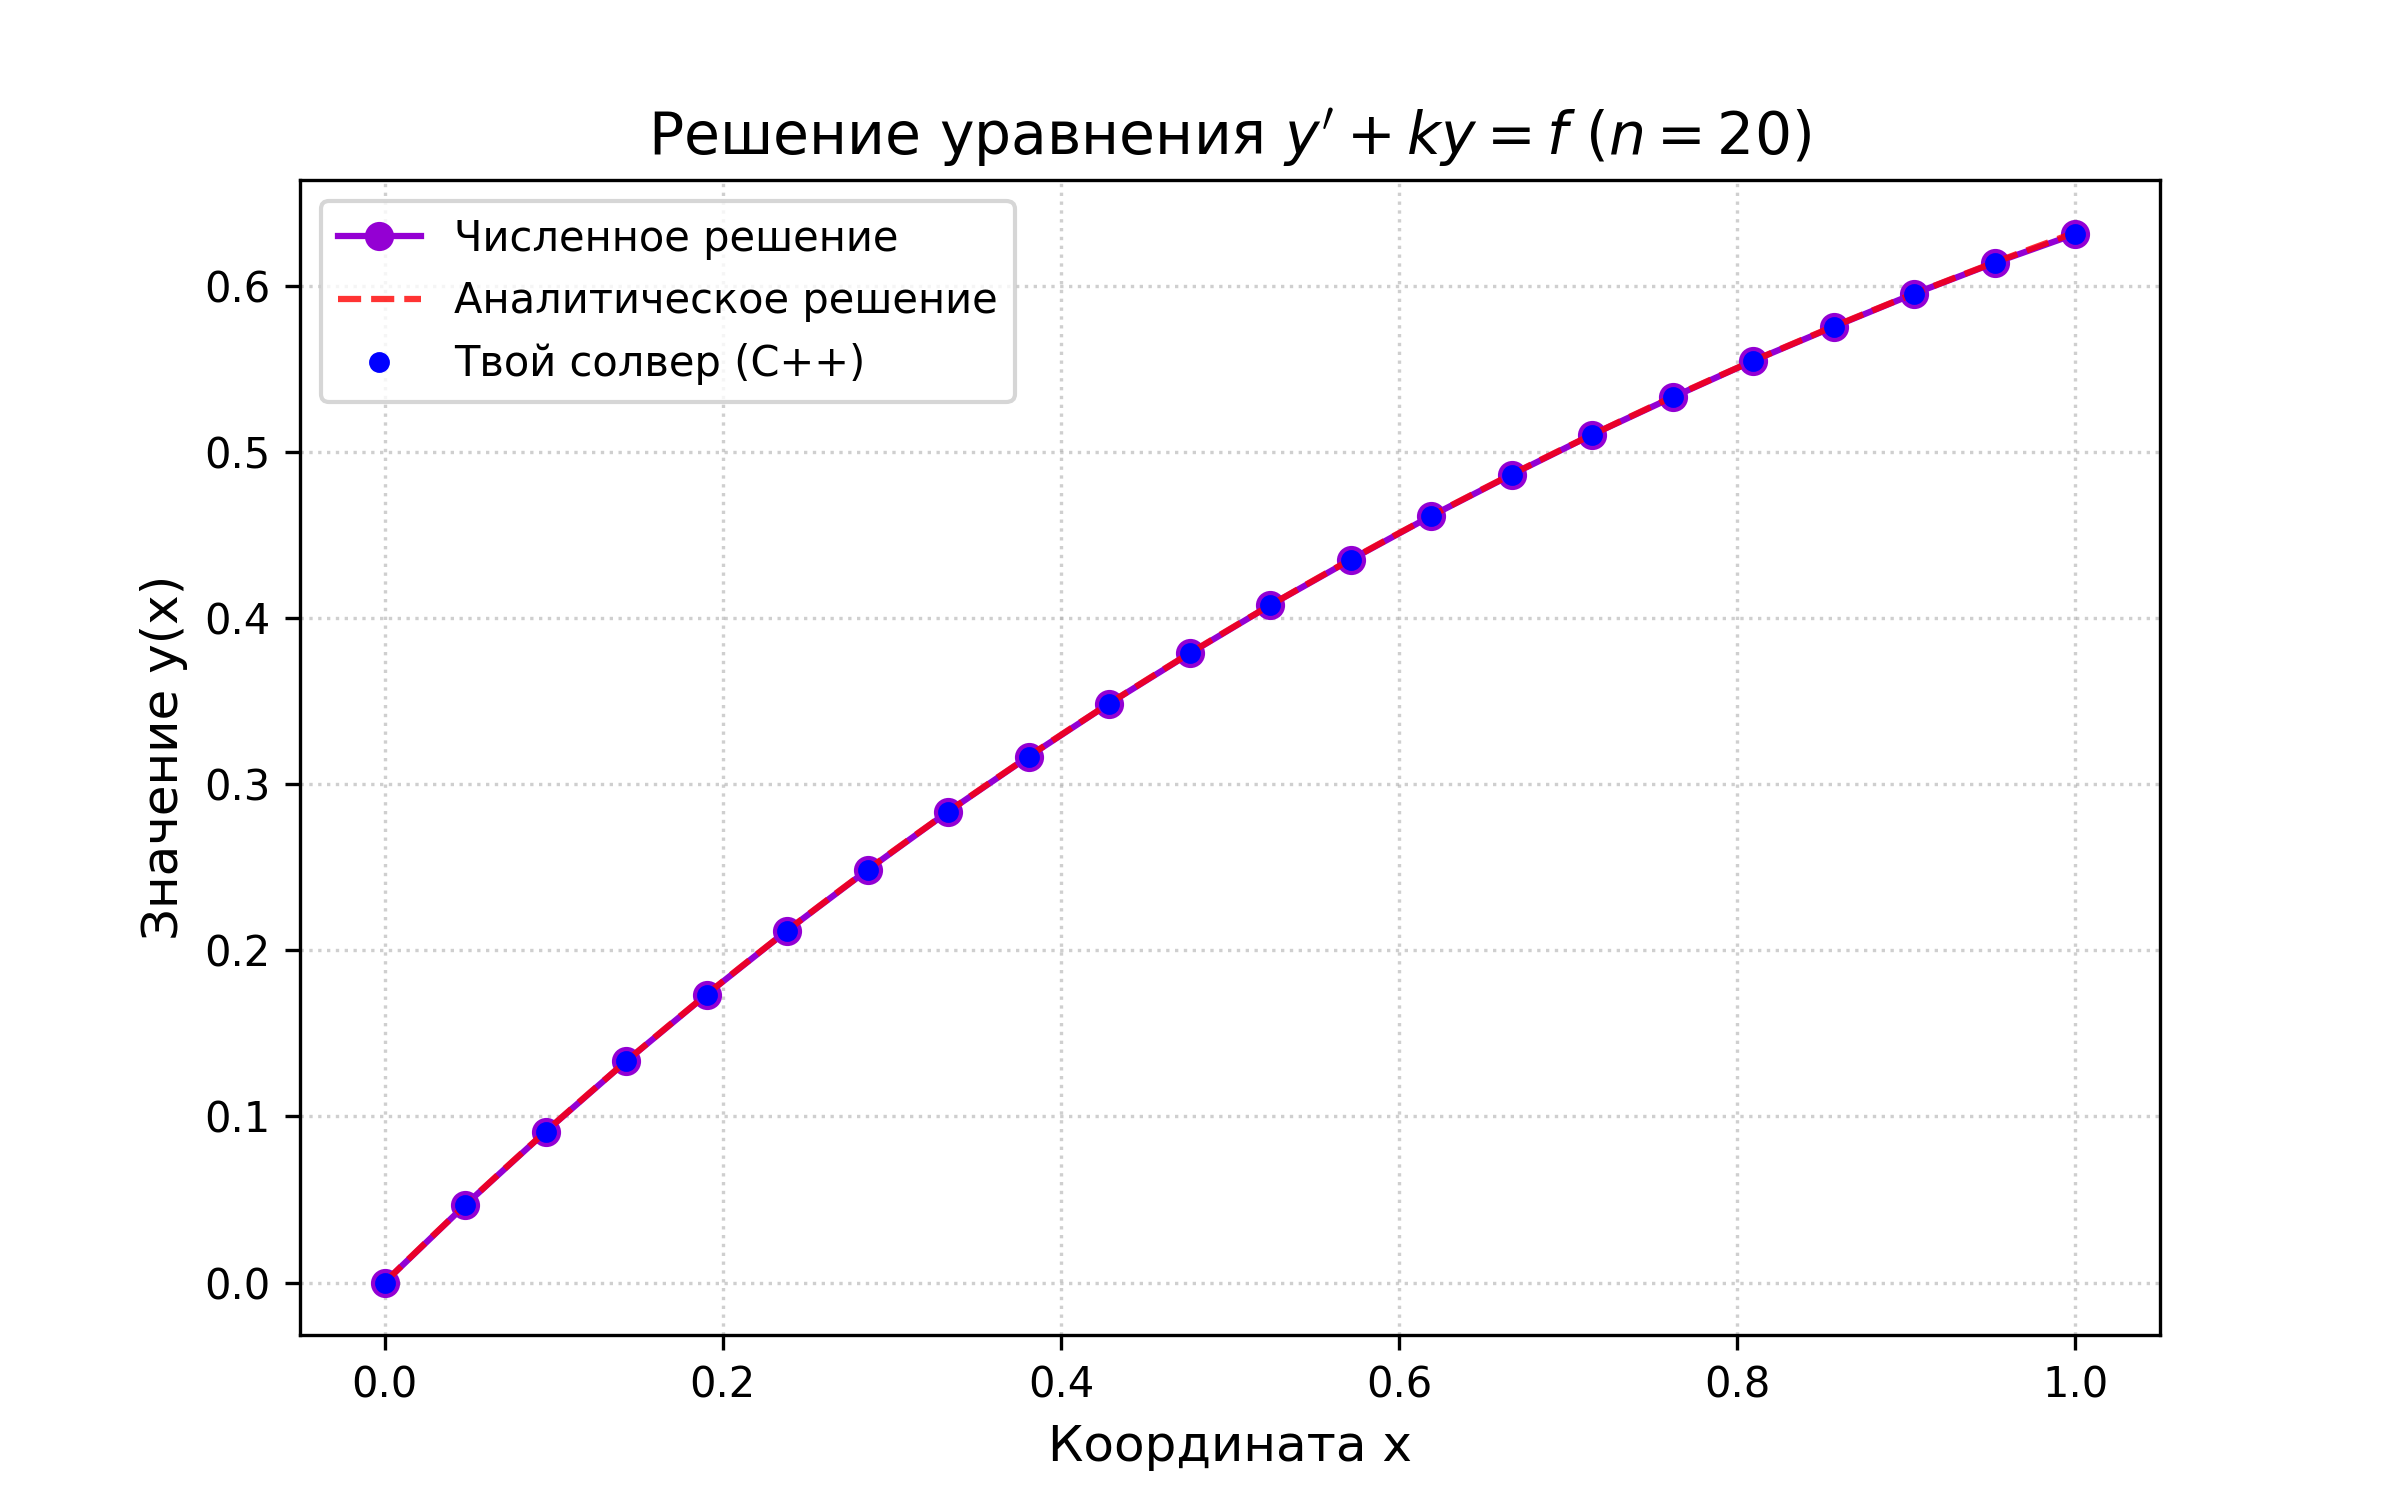


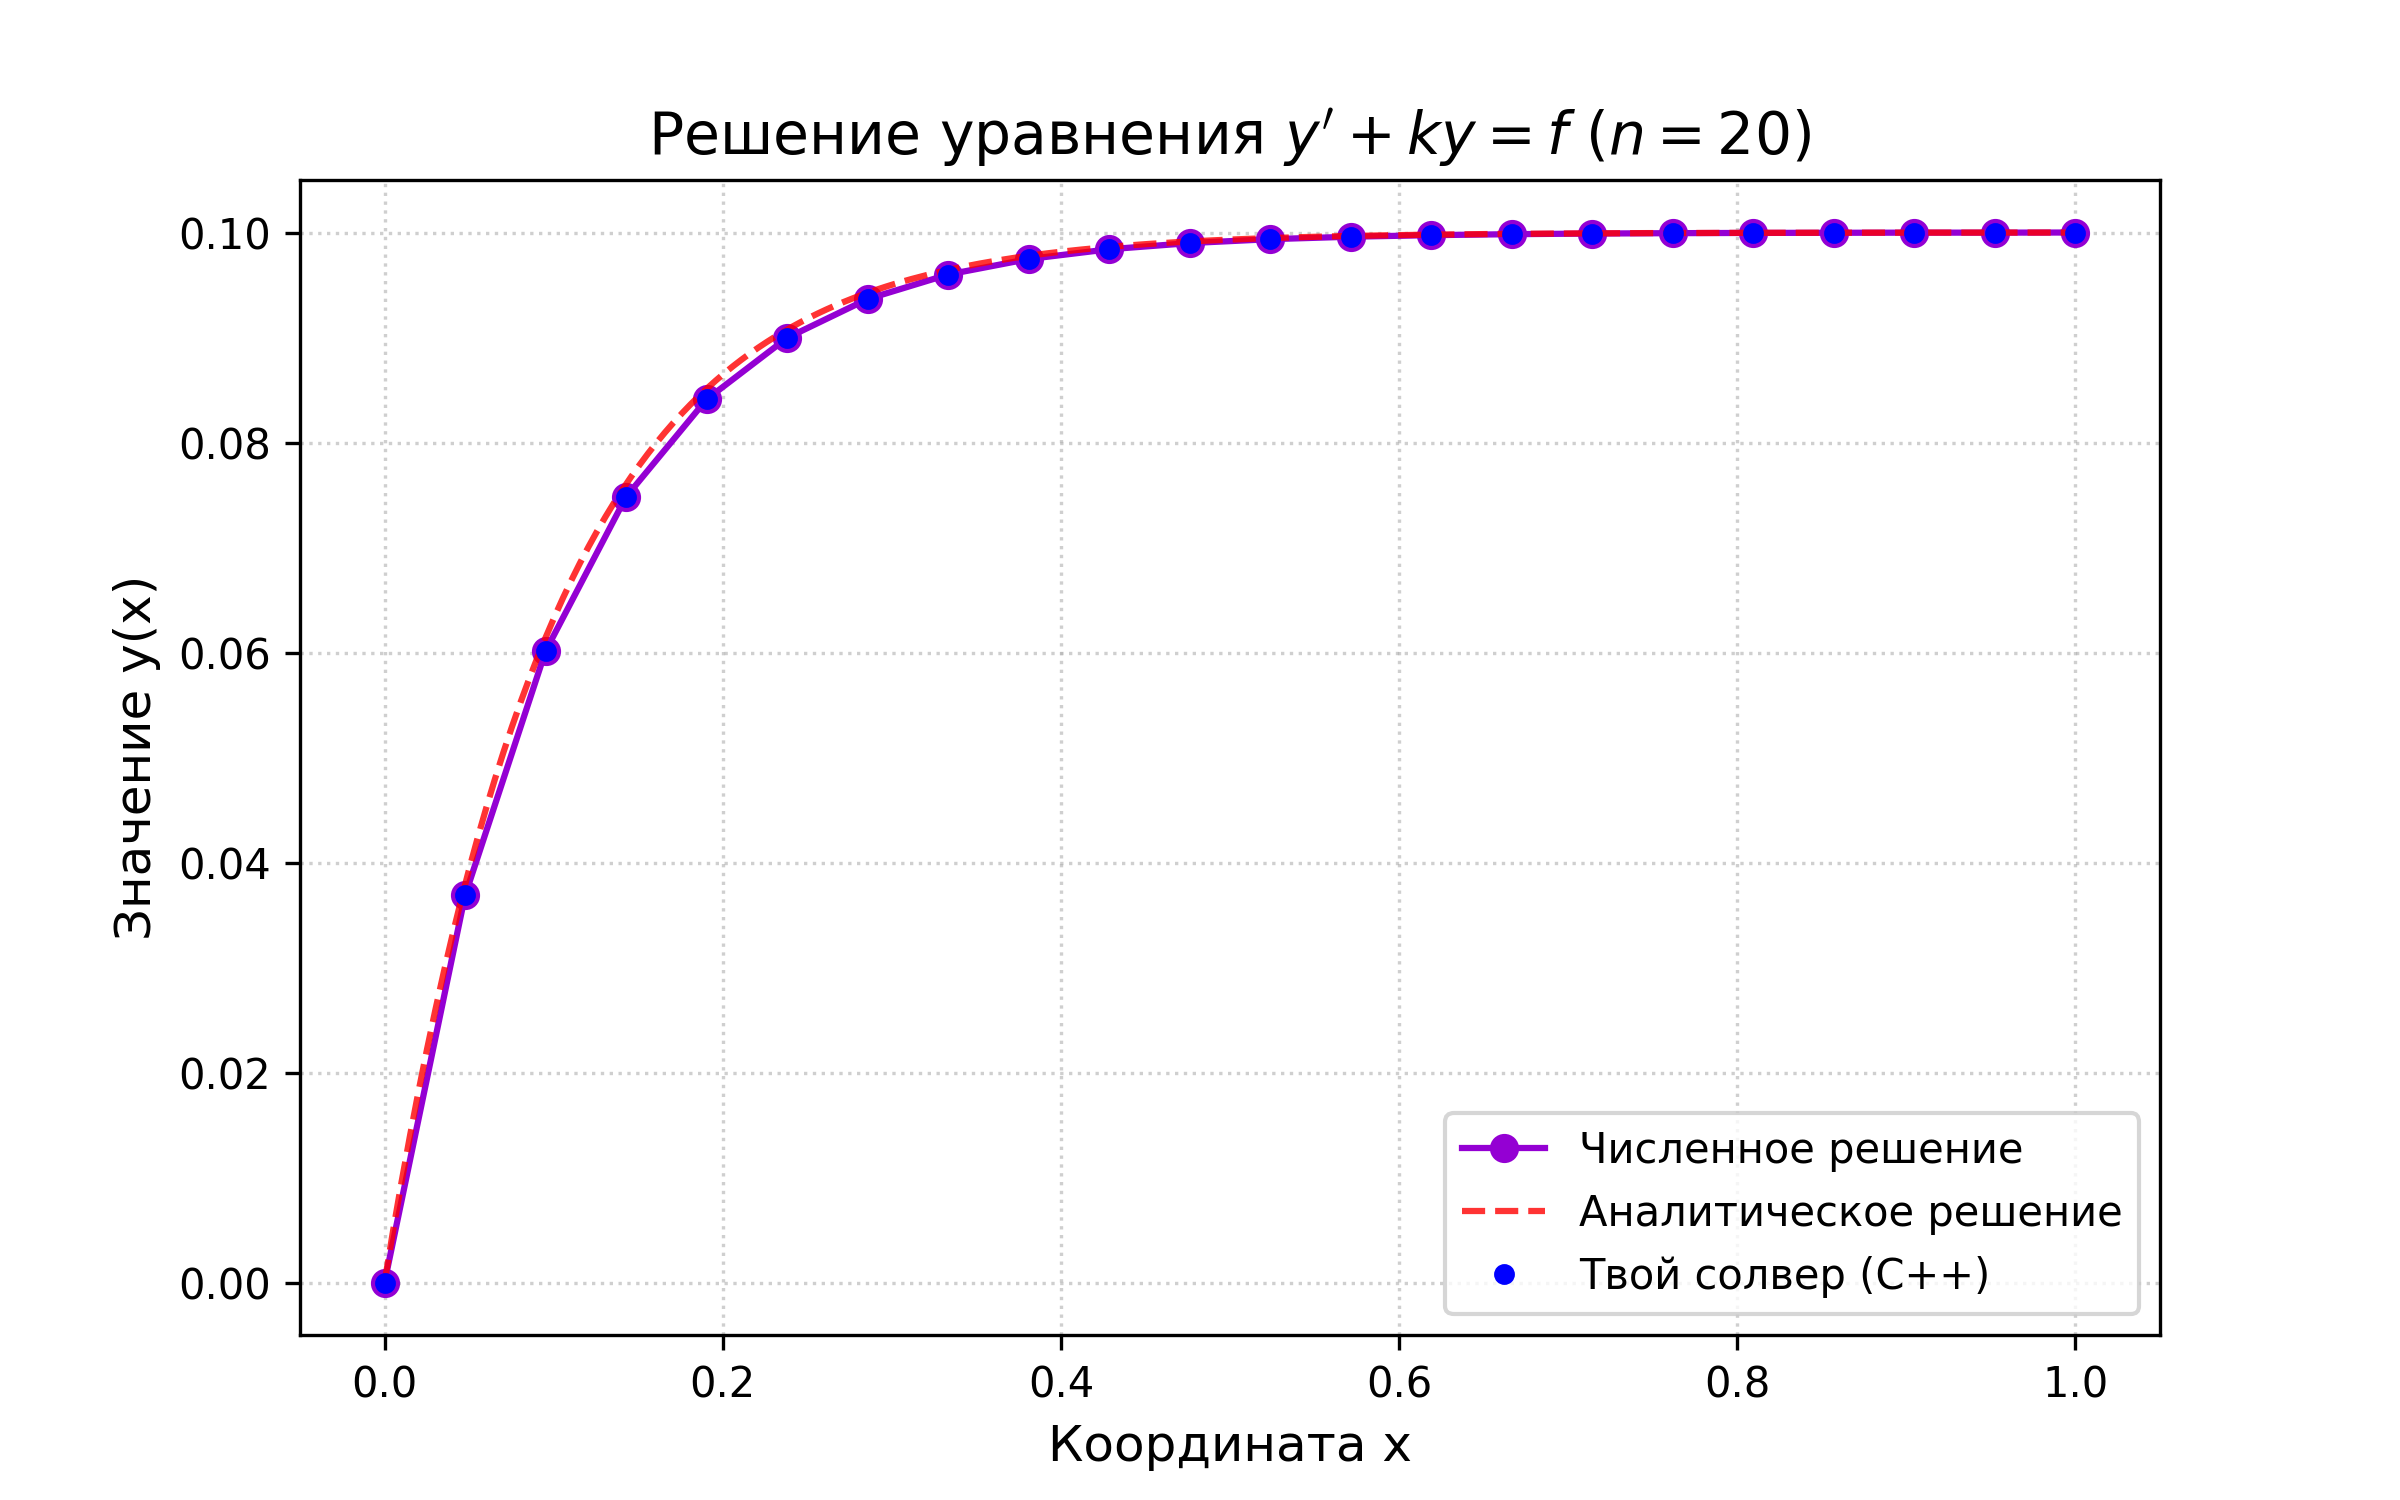


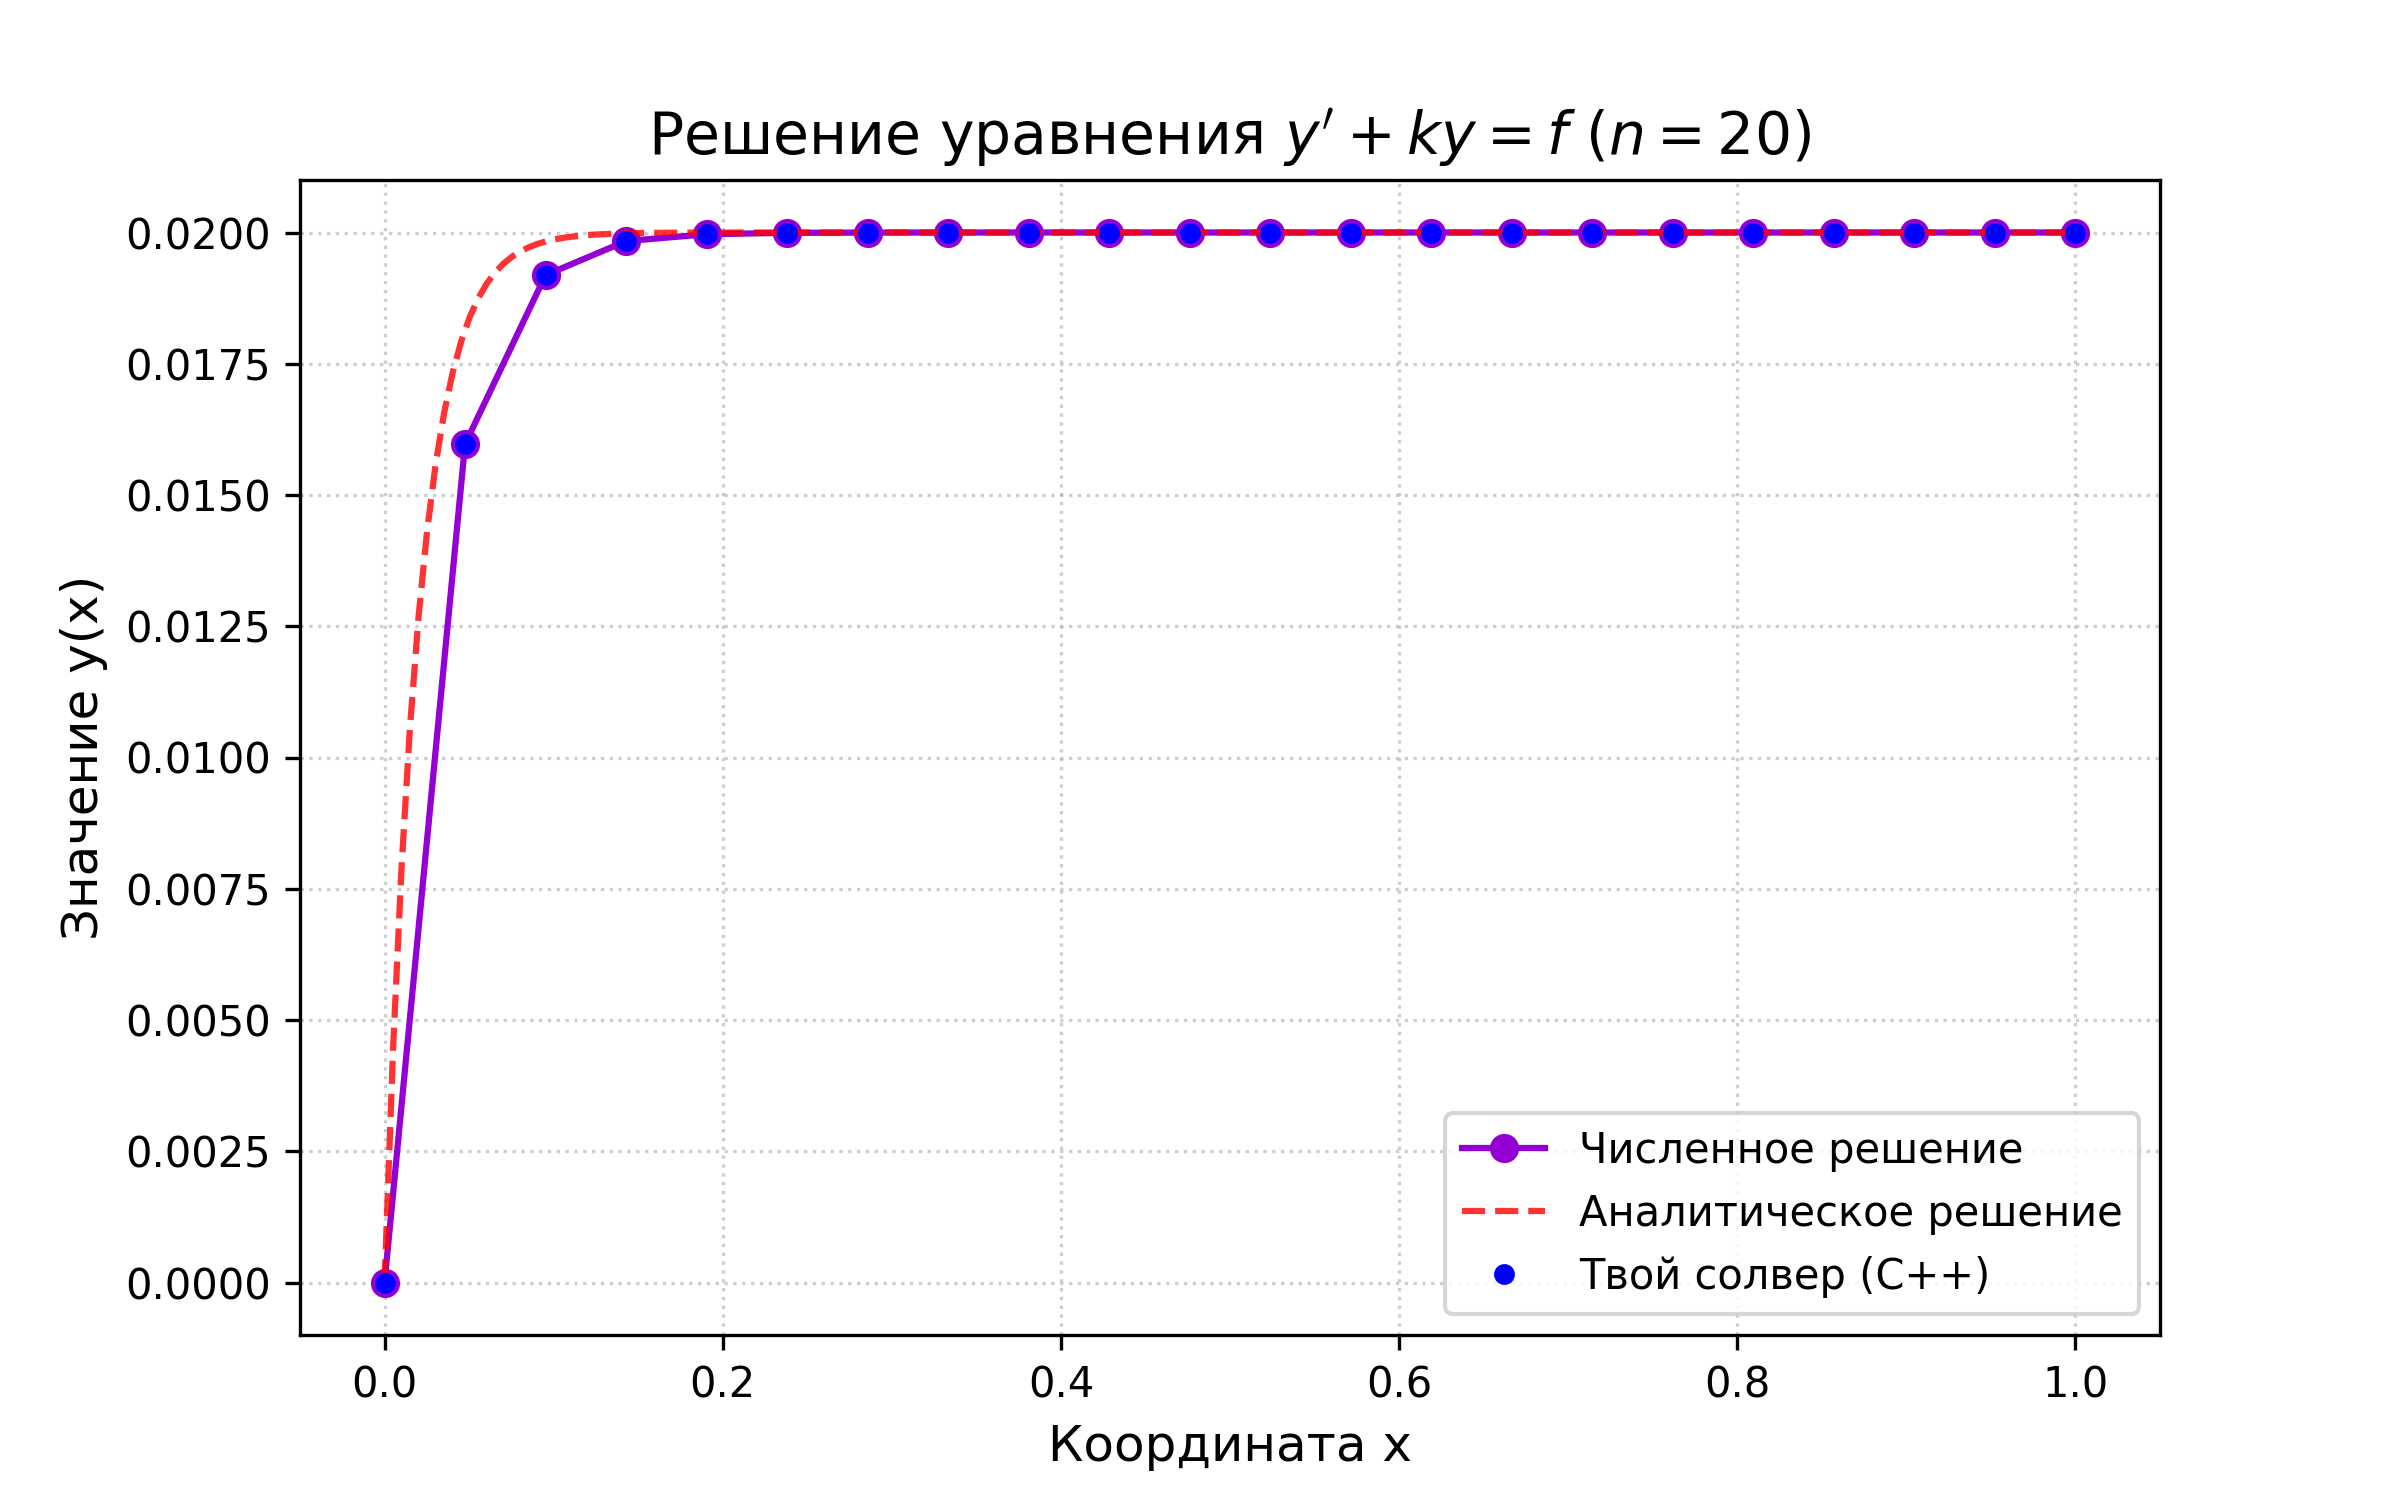

In [12]:
import base64
from IPython.display import display, HTML
import os

all_images = [
    "test_5x5.png", "test_6x6.png", "test_7x7.png", 
    "pic2.png", "pic3.png", "pic4.png"
]

def display_embedded_img(file_path):
    if os.path.exists(file_path):
        with open(file_path, "rb") as f:
            data = f.read()
            # Кодируем картинку в base64
            encoded = base64.b64encode(data).decode()
        
        # Создаем HTML-тег с данными прямо внутри src
        html = f'<div style="margin-bottom: 20px;"><p><b>Файл: {file_path}</b></p>'
        html += f'<img src="data:image/png;base64,{encoded}" style="width: 80%; max-width: 800px;"></div>'
        display(HTML(html))
    else:
        print(f"!!! ОШИБКА: {file_path} не найден.")

print("--- ЭМБЕДИНГ КАРТИНОК ДЛЯ ЭКСПОРТА ---")
for img in all_images:
    display_embedded_img(img)